In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import LabelEncoder, StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_curve, auc
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.utils import resample
from imblearn.over_sampling import SMOTE

df = pd.read_csv('loan_data.csv')
print(f'Размер датасета: {df.shape}')
df.head()

Размер датасета: (45000, 14)


,person_age,person_gender,person_education,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file,loan_status
0,22.0,female,Master,71948.0,0,RENT,35000.0,PERSONAL,16.02,0.49,3.0,561,No,1
1,21.0,female,High School,12282.0,0,OWN,1000.0,EDUCATION,11.14,0.08,2.0,504,Yes,0
2,25.0,female,High School,12438.0,3,MORTGAGE,5500.0,MEDICAL,12.87,0.44,3.0,635,No,1
3,23.0,female,Bachelor,79753.0,0,RENT,35000.0,MEDICAL,15.23,0.44,2.0,675,No,1
4,24.0,male,Master,66135.0,1,RENT,35000.0,MEDICAL,14.27,0.53,4.0,586,No,1


In [2]:
print(df.info())
print(df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45000 entries, 0 to 44999
Data columns (total 14 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   person_age                      45000 non-null  float64
 1   person_gender                   45000 non-null  object 
 2   person_education                45000 non-null  object 
 3   person_income                   45000 non-null  float64
 4   person_emp_exp                  45000 non-null  int64  
 5   person_home_ownership           45000 non-null  object 
 6   loan_amnt                       45000 non-null  float64
 7   loan_intent                     45000 non-null  object 
 8   loan_int_rate                   45000 non-null  float64
 9   loan_percent_income             45000 non-null  float64
 10  cb_person_cred_hist_length      45000 non-null  float64
 11  credit_score                    45000 non-null  int64  
 12  previous_loan_defaults_on_file  

In [3]:
categorical_cols = ['person_gender', 'person_education', 'person_home_ownership', 'loan_intent', 'previous_loan_defaults_on_file']
label_encoders = {}
for col in categorical_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    label_encoders[col] = le

In [4]:
numeric_cols = ['person_age', 'person_income', 'person_emp_exp', 'loan_amnt', 'loan_int_rate', 'loan_percent_income', 'cb_person_cred_hist_length', 'credit_score']
scaler = StandardScaler()
df[numeric_cols] = scaler.fit_transform(df[numeric_cols])

In [14]:
df.to_excel("loan_data.xlsx", index=False)

In [5]:
X = df.drop(columns=['loan_status'])
y = df['loan_status']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [6]:
# 1. Обычная логистическая регрессия
logreg = LogisticRegression(random_state=42, max_iter=1000)
logreg.fit(X_train, y_train)
y_pred = logreg.predict(X_test)

# 2. С L1 и L2 регуляризацией
logreg_l1 = LogisticRegression(penalty='l1', solver='liblinear', random_state=42, max_iter=1000)
logreg_l2 = LogisticRegression(penalty='l2', random_state=42, max_iter=1000)

# Подбор параметра C через GridSearchCV
param_grid = {'C': [0.001, 0.01, 0.1, 1, 10, 100]}
grid_l1 = GridSearchCV(logreg_l1, param_grid, cv=5, scoring='f1')
grid_l2 = GridSearchCV(logreg_l2, param_grid, cv=5, scoring='f1')

grid_l1.fit(X_train, y_train)
grid_l2.fit(X_train, y_train)

# Оценка моделей
models = {
    'LogReg': logreg,
    'LogReg L1': grid_l1.best_estimator_,
    'LogReg L2': grid_l2.best_estimator_
}

for name, model in models.items():
    y_pred = model.predict(X_test)
    print(f"{name}:")
    print(f"  Accuracy: {accuracy_score(y_test, y_pred):.2f}")
    print(f"  Precision: {precision_score(y_test, y_pred):.2f}")
    print(f"  Recall: {recall_score(y_test, y_pred):.2f}")
    print(f"  F1: {f1_score(y_test, y_pred):.2f}")
    print("  Confusion Matrix:")
    print(confusion_matrix(y_test, y_pred))
    print()

LogReg:
  Accuracy: 0.90
  Precision: 0.78
  Recall: 0.75
  F1: 0.76
  Confusion Matrix:
[[6573  427]
 [ 503 1497]]

LogReg L1:
  Accuracy: 0.90
  Precision: 0.78
  Recall: 0.75
  F1: 0.77
  Confusion Matrix:
[[6575  425]
 [ 496 1504]]

LogReg L2:
  Accuracy: 0.90
  Precision: 0.78
  Recall: 0.75
  F1: 0.76
  Confusion Matrix:
[[6571  429]
 [ 501 1499]]



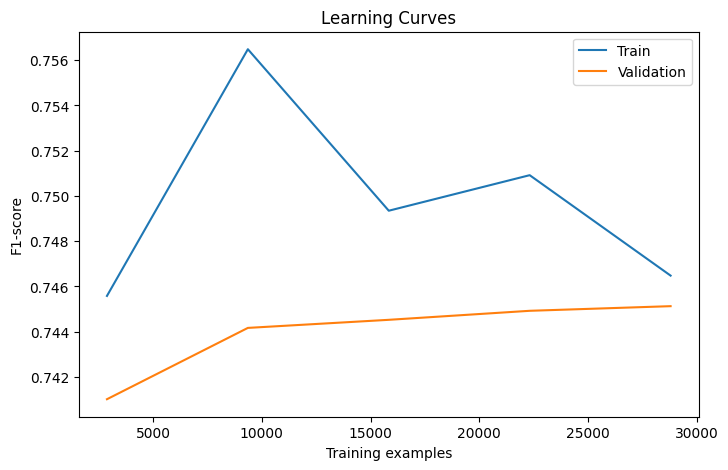

In [7]:
from sklearn.model_selection import learning_curve

train_sizes, train_scores, val_scores = learning_curve(
    logreg, X_train, y_train, cv=5, scoring='f1', n_jobs=-1
)

plt.figure(figsize=(8,5))
plt.plot(train_sizes, np.mean(train_scores, axis=1), label='Train')
plt.plot(train_sizes, np.mean(val_scores, axis=1), label='Validation')
plt.xlabel('Training examples')
plt.ylabel('F1-score')
plt.legend()
plt.title('Learning Curves')
plt.show()

loan_status
0    0.777778
1    0.222222
Name: proportion, dtype: float64


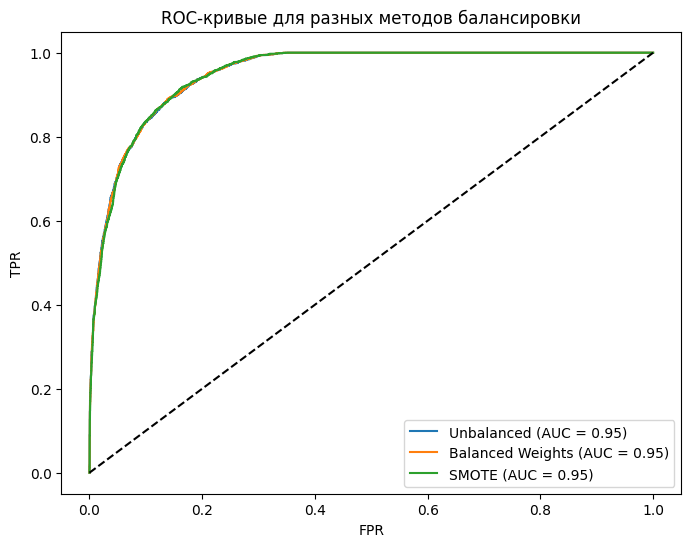

In [8]:
# Проверим дисбаланс
print(df['loan_status'].value_counts(normalize=True))

# 1. Без балансировки
logreg_unbalanced = LogisticRegression(random_state=42, max_iter=1000)
logreg_unbalanced.fit(X_train, y_train)

# 2. С балансировкой весов классов
logreg_balanced = LogisticRegression(class_weight='balanced', random_state=42, max_iter=1000)
logreg_balanced.fit(X_train, y_train)

# 3. SMOTE
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)
logreg_smote = LogisticRegression(random_state=42, max_iter=1000)
logreg_smote.fit(X_train_smote, y_train_smote)

# Сравнение ROC-кривых
fig, ax = plt.subplots(figsize=(8,6))
for name, model in [('Unbalanced', logreg_unbalanced), ('Balanced Weights', logreg_balanced), ('SMOTE', logreg_smote)]:
    y_prob = model.predict_proba(X_test)[:,1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc_score = auc(fpr, tpr)
    ax.plot(fpr, tpr, label=f'{name} (AUC = {auc_score:.2f})')

ax.plot([0,1], [0,1], 'k--')
ax.set_xlabel('FPR')
ax.set_ylabel('TPR')
ax.legend()
ax.set_title('ROC-кривые для разных методов балансировки')
plt.show()

In [17]:
df['loan_status'].unique()

array([1, 0])

In [9]:
# Создадим многоклассовую задачу: предсказание loan_intent
X_multi = df.drop(columns=['loan_intent'])
y_multi = df['loan_intent']

X_train_m, X_test_m, y_train_m, y_test_m = train_test_split(X_multi, y_multi, test_size=0.2, random_state=42, stratify=y_multi)

# Модели
models_multi = {
    'LogReg (OvR)': LogisticRegression(multi_class='ovr', max_iter=1000),
    'kNN': KNeighborsClassifier(),
    'SVM (OvO)': SVC(decision_function_shape='ovo')
}

# Обучение и оценка
results = {}
for name, model in models_multi.items():
    model.fit(X_train_m, y_train_m)
    y_pred_m = model.predict(X_test_m)
    results[name] = {
        'Accuracy': accuracy_score(y_test_m, y_pred_m),
        'F1 (macro)': f1_score(y_test_m, y_pred_m, average='macro')
    }

# Таблица сравнения
results_df = pd.DataFrame(results).T
print(results_df)

c:\Users\Пользователь\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(


              Accuracy  F1 (macro)
LogReg (OvR)  0.236556    0.168229
kNN           0.195111    0.185411
SVM (OvO)     0.248778    0.179610
